<a href="https://colab.research.google.com/github/AliyahAlabdali/Yaqidh/blob/main/Yaqidh_Fall_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Download The Dataset

In [ ]:
!pip install ultralytics
!pip install roboflow
from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import userdata
import yaml
import glob, os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

from IPython.display import display, Image
from PIL import Image as PILImage
import random


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 72.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings wi

In [ ]:
!pip install roboflow

from roboflow import Roboflow
api_key = userdata.get('API_KEY_GRAYSCALE')

rf = Roboflow(api_key)
project = rf.workspace("yaqidh").project("children-fall_detection")
version = project.version(29)
dataset = version.download("yolov8")

DATASET_PATH = dataset.location
data_path = f"{DATASET_PATH}/data.yaml"
print(f"\nDataset downloaded to: {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to children-fall_detection-29 in yolov8:: 100%|██████████| 7710/7710 [00:00<00:00, 7715.35it/s]


Dataset downloaded to: /content/children-fall_detection-29


In [ ]:
# Swap labels so 0 = Non fall and 1 = Fall (Roboflow sorts alphabetically)
print("\n--- 1. Starting Label Swap ---")
folders_to_update = ['train/labels', 'valid/labels', 'test/labels']
total_files_changed = 0

for folder in folders_to_update:
    folder_path = os.path.join(DATASET_PATH, folder)

    if not os.path.exists(folder_path):
        continue

    count = 0
    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            file_path = os.path.join(folder_path, filename)

            # Read the file
            with open(file_path, 'r') as file:
                lines = file.readlines()

            # Swap 0s and 1s
            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if parts:
                    if parts[0] == '0':
                        parts[0] = '1'
                    elif parts[0] == '1':
                        parts[0] = '0'
                    new_lines.append(' '.join(parts) + '\n')

            # Overwrite the file
            with open(file_path, 'w') as file:
                file.writelines(new_lines)

            count += 1
            total_files_changed += 1

    if count > 0:
        print(f"Swapped classes in {count} files inside {folder}")

print(f"Total label files safely updated: {total_files_changed}")

# Update the data.yaml file
print("\n--- 2. Updating data.yaml ---")
if os.path.exists(data_path):
    with open(data_path, 'r') as f:
        config = yaml.safe_load(f)

    # Force the correct names order so 1 = Fall
    config['names'] = {0: 'Non fall', 1: 'Fall'}

    # Fix the paths to absolute paths
    config['train'] = os.path.join(DATASET_PATH, 'train/images')
    config['val'] = os.path.join(DATASET_PATH, 'valid/images')

    # Check if a test folder actually exists before adding it
    test_path = os.path.join(DATASET_PATH, 'test/images')
    if os.path.exists(test_path):
        config['test'] = test_path
    elif 'test' in config:
        del config['test']

    # Save the updated yaml
    with open(data_path, 'w') as f:
        yaml.dump(config, f, sort_keys=False)
    print("Successfully updated data.yaml!")
else:
    print(f"Error: data.yaml not found at {data_path}")

# 5. Verify dataset splits
print("\n--- 3. Dataset Split Verification ---")
if os.path.exists(data_path):
    sets = {
        "Train": config.get('train', ''),
        "Valid": config.get('val', ''),
        "Test":  config.get('test', '')
    }

    for set_name, path in sets.items():
        if path and os.path.exists(path):
            img_count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
            print(f"{set_name} Set: {img_count} images ready at {path}")


--- 1. Starting Label Swap ---
Swapped classes in 2703 files inside train/labels
Swapped classes in 573 files inside valid/labels
Swapped classes in 573 files inside test/labels
Total label files safely updated: 3849

--- 2. Updating data.yaml ---
Successfully updated data.yaml!

--- 3. Dataset Split Verification ---
Train Set: 2703 images ready at /content/children-fall_detection-29/train/images
Valid Set: 573 images ready at /content/children-fall_detection-29/valid/images
Test Set: 573 images ready at /content/children-fall_detection-29/test/images


In [ ]:
# Clone the Human-Fall-Detection repo
!git clone https://github.com/Tomotsugu-dev/Human-Fall-Detection.git
%cd /content/Human-Fall-Detection/models

Cloning into 'Human-Fall-Detection'...
remote: Enumerating objects: 2042, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 2042 (delta 8), reused 11 (delta 5), pack-reused 2012 (from 3)
Receiving objects: 100% (2042/2042), 157.35 MiB | 35.07 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (1038/1038), done.
/content/Human-Fall-Detection/models


In [ ]:
# Load pretrained adult fall model
pretrained_weight = "/content/Human-Fall-Detection/models/yolo_fall/best.pt"
model = YOLO(pretrained_weight)


# Baseline Performance on Child Test Set

In [ ]:
# Baseline evaluation of pretrained adult model on child test set (before transfer learning)
metrics_before = model.val(
    data=data_path,
    split="test"
)

print("Before Transfer Learning:", metrics_before)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1554.3±415.5 MB/s, size: 43.0 KB)
val: Scanning /content/children-fall_detection-29/test/labels... 573 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 573/573 2.0Kit/s 0.3s
val: New cache created: /content/children-fall_detection-29/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 4.6it/s 7.8s
                   all        573       1098      0.469      0.389      0.356       0.16
                Normal        250        554      0.468      0.304      0.284     0.0973
                  Fall        530        544       0.47      0.474      0.428      0.222
Speed: 1.1ms preprocess, 5.4ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/Human-Fall-Detection/models/

# Transfer Learning (Training)



> Freeze



In [ ]:
# PHASE 1: Transfer Learning (freeze backbone, train head)
# Freeze first 10 layers (backbone), train detection head
# We intentionally use YOLO's highly optimized default learning rate (0.01 lr)
# and default optimizer (SGD) here to maximize performance and training stability.

model.train(
    data=data_path,
    epochs=30,
    imgsz=640,
    batch=16,
    freeze=10,
    pretrained=True,
    save_period=5,
    name="freeze_phase",
)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/children-fall_detection-29/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/Human-Fall-Detection/models/yolo_fall/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=freeze_phase, nbs=64, nms=False, opset=None, optimize=Fa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fdda7435400>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804



> Unfreeze



In [ ]:
# PHASE 2: Partial Unfreezing
# Goal: Further adapt the model to child-specific features (e.g., child body proportions and unique fall postures).
# Load the best weights from the previous training phase for continued fine-tuning
model_path_after_first_train = (
    "/content/Human-Fall-Detection/models/runs/detect/freeze_phase/weights/best.pt"
)
model = YOLO(model_path_after_first_train)

# We lower the learning rate (0.001) to protect previously learned weights.
model.train(
    data=data_path,
    epochs=20,
    imgsz=640,
    batch=16,
    lr0=0.001,
    freeze=5,
    save_period=5,
    name="partial_unfreeze"
)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/children-fall_detection-29/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=5, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/Human-Fall-Detection/models/runs/detect/freeze_phase/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=partial_unfreeze, nbs=64, nms=Fal

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fdda74d7b00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

# Fine-Tuning

In [ ]:
# PHASE 3: Final Fine-Tuning
# Load the best weights from the previous phase for continued training
model_path_after_second_train = "/content/Human-Fall-Detection/models/runs/detect/partial_unfreeze/weights/best.pt"
model = YOLO(model_path_after_second_train)

# Unfreeze ALL layers to get the best accuracy.
# Very low learning rate (0.0001) for safe, small updates across the whole model.
model.train(
    data=data_path,
    epochs=20,
    imgsz=640,
    batch=16,
    lr0=0.0001,
    freeze=0,
    save_period=5,
    name="finetune"
)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/children-fall_detection-29/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/Human-Fall-Detection/models/runs/detect/partial_unfreeze/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune, nbs=64, nms=False,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fdde084aae0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

# Evaluation

In [ ]:
# Test the fine-tuned model on child dataset to measure performance after transfer learning
metrics = model.val(data=data_path, split="test")
print("Final Evaluation Metrics on Test Set:", metrics)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1803.7±665.2 MB/s, size: 54.8 KB)
val: Scanning /content/children-fall_detection-29/test/labels.cache... 573 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 573/573 160.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 5.5it/s 6.6s
                   all        573       1098       0.89      0.824      0.875      0.552
              Non fall        250        554       0.85      0.774       0.82      0.459
                  Fall        530        544       0.93      0.873       0.93      0.646
Speed: 1.0ms preprocess, 5.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/Human-Fall-Detection/models/runs/detect/val3
Final Evaluation Metrics on Test Set: ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: 

# Final Results Visualization

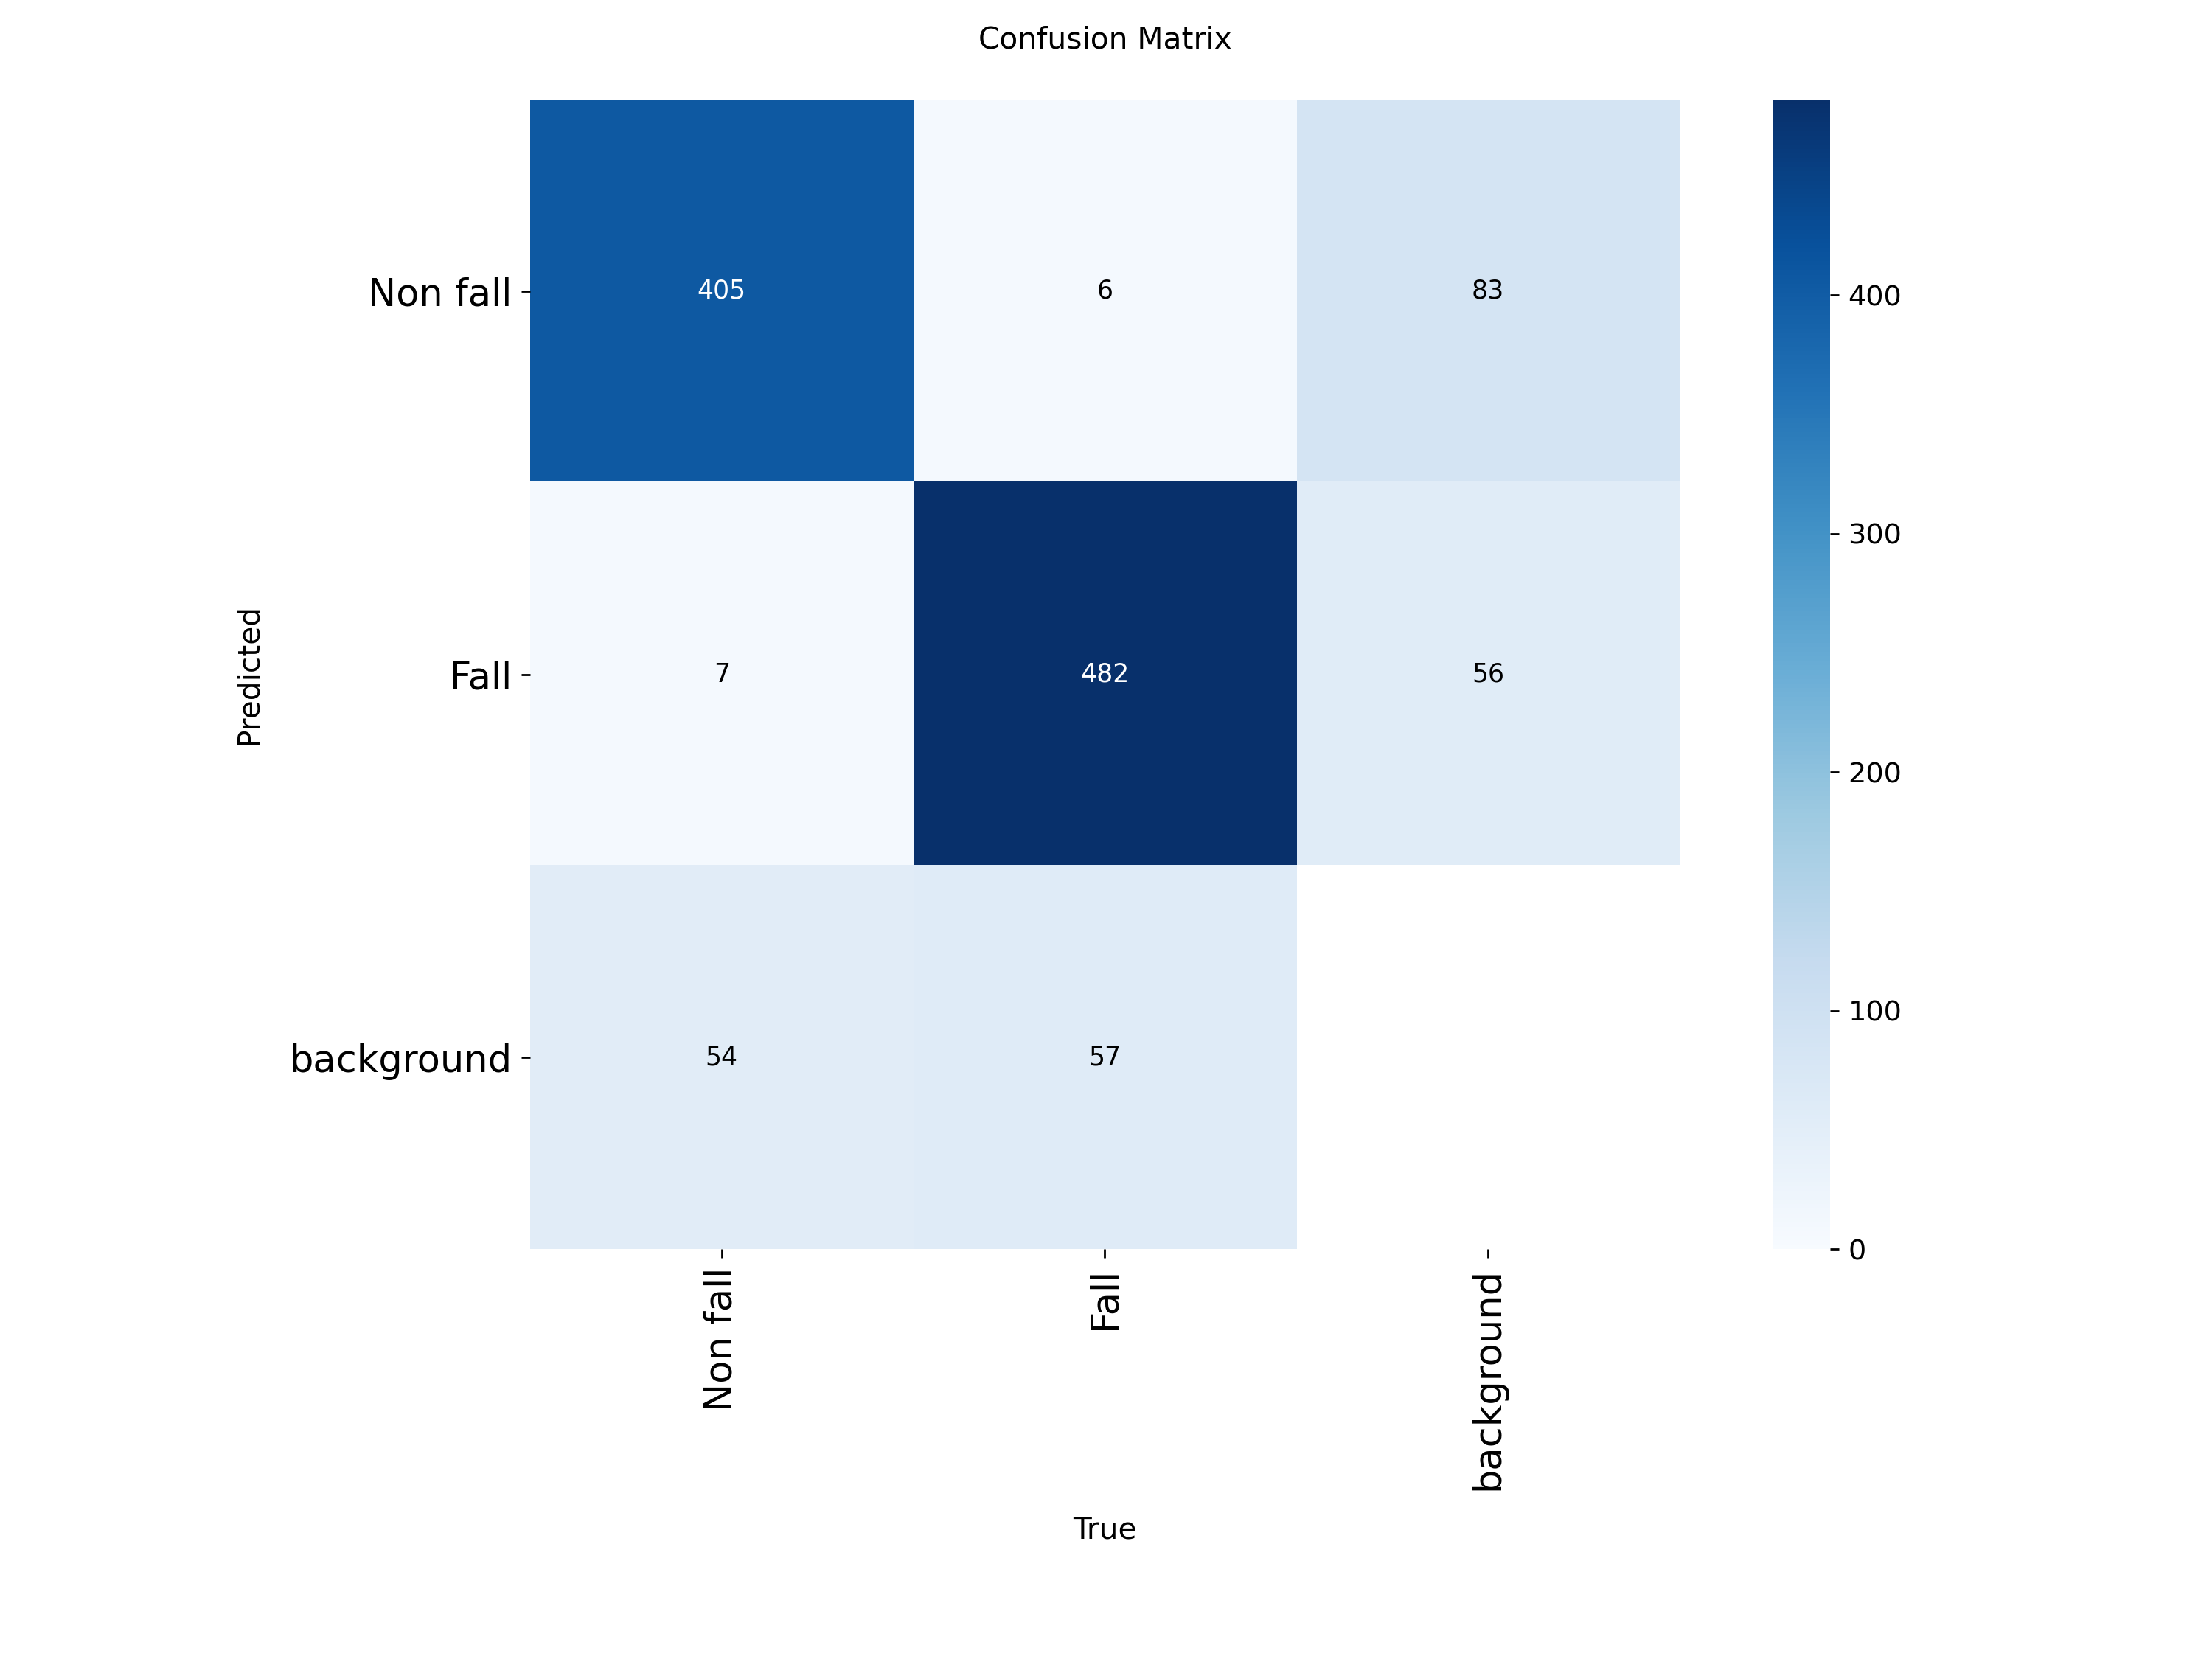


image 1/573 /content/children-fall_detection-29/test/images/FUNNY-Babies-On-The-Slides-FAILS-Compilation_mp4-0009_jpg.rf.88110545dfa58de054dd34d5f3e9eb59.jpg: 384x640 1 Fall, 60.3ms
image 2/573 /content/children-fall_detection-29/test/images/FUNNY-Babies-On-The-Slides-FAILS-Compilation_mp4-0058_jpg.rf.263881d118f80260002defe8069587b2.jpg: 384x640 (no detections), 11.1ms
image 3/573 /content/children-fall_detection-29/test/images/FUNNY-Babies-On-The-Slides-FAILS-Compilation_mp4-0093_jpg.rf.95a539ce42d014e994bff4b306ff57a5.jpg: 384x640 1 Fall, 10.7ms
image 4/573 /content/children-fall_detection-29/test/images/FUNNY-Babies-On-The-Slides-FAILS-Compilation_mp4-0094_jpg.rf.a4a27e7a5da7b449ae89049a5538681b.jpg: 384x640 1 Fall, 10.6ms
image 5/573 /content/children-fall_detection-29/test/images/FUNNY-Babies-On-The-Slides-FAILS-Compilation_mp4-0145_jpg.rf.ebab5ee5a2062aeae3bc8a42b1dd1b57.jpg: 384x640 1 Fall, 10.6ms
image 6/573 /content/children-fall_detection-29/test/images/FUNNY-Babies-On-The-

In [ ]:
# Display the Confusion Matrix to see how the model performs on children
conf_matrix_path = '/content/Human-Fall-Detection/models/runs/detect/finetune/confusion_matrix.png'

if os.path.exists(conf_matrix_path):
    display(Image(filename=conf_matrix_path, width=600))

# Run inference on a test image to verify results
results = model.predict(source=f"{dataset.location}/test/images", save=True, conf=0.5)

# download model files

In [ ]:
# Download model files
!zip -r files.zip /content/Human-Fall-Detection/models/runs/detect/finetune/
from google.colab import files
files.download('files.zip')

  adding: content/Human-Fall-Detection/models/runs/detect/finetune/ (stored 0%)
  adding: content/Human-Fall-Detection/models/runs/detect/finetune/BoxP_curve.png (deflated 14%)
  adding: content/Human-Fall-Detection/models/runs/detect/finetune/labels.jpg (deflated 29%)
  adding: content/Human-Fall-Detection/models/runs/detect/finetune/results.csv (deflated 59%)
  adding: content/Human-Fall-Detection/models/runs/detect/finetune/results.png (deflated 7%)
  adding: content/Human-Fall-Detection/models/runs/detect/finetune/val_batch1_pred.jpg (deflated 6%)
  adding: content/Human-Fall-Detection/models/runs/detect/finetune/train_batch2.jpg (deflated 3%)
  adding: content/Human-Fall-Detection/models/runs/detect/finetune/val_batch0_labels.jpg (deflated 8%)
  adding: content/Human-Fall-Detection/models/runs/detect/finetune/train_batch0.jpg (deflated 6%)
  adding: content/Human-Fall-Detection/models/runs/detect/finetune/val_batch1_labels.jpg (deflated 6%)
  adding: content/Human-Fall-Detection/m

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>